# Лаба 1

Верещагин И.В. "Мулла Рахим и Мулла Керим по дороге на базар ссорятся"

![title](quarrel.jpg)

In [84]:
import cv2
import numpy
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import Video

In [45]:
image_original = cv2.imread("quarrel.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

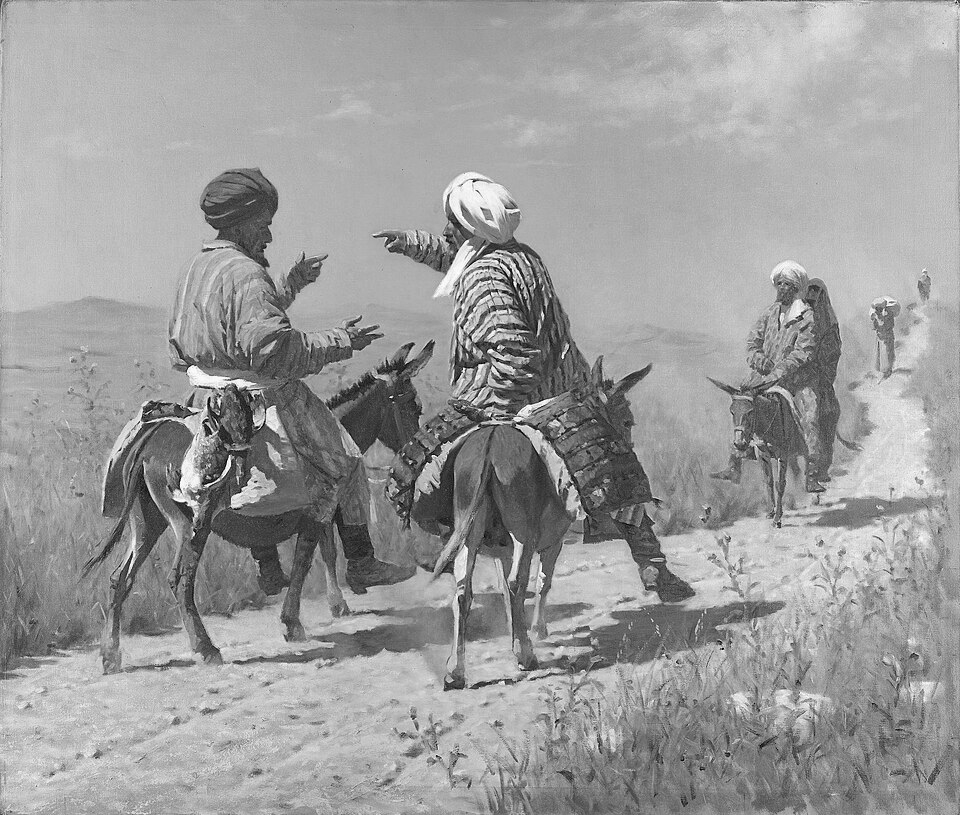

In [48]:
grayscale_naive = numpy.zeros(image.shape[:2], dtype=numpy.uint8)

for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        grayscale_naive[y, x] = int(image[y, x].sum() / 3)
        
Image.fromarray(grayscale_naive,  mode="L")

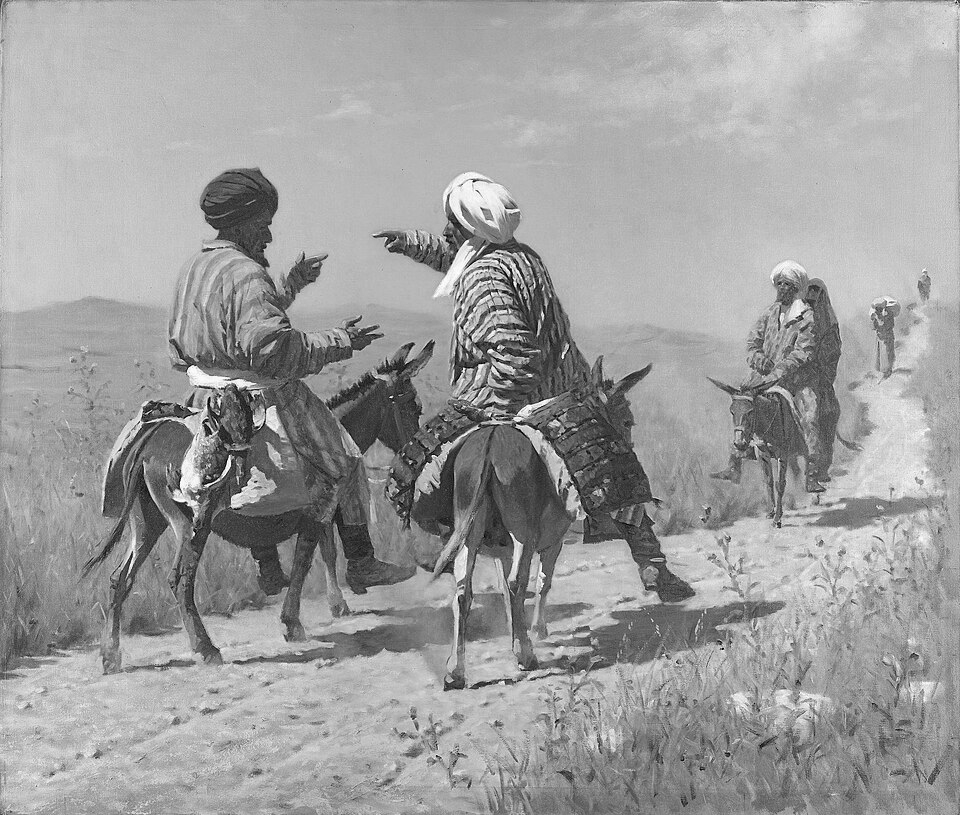

In [57]:
grayscale_formula = numpy.zeros(image.shape[:2], dtype=numpy.uint8)

for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        grayscale_formula[y, x] = int((image[y, x] * numpy.array([0.3, 0.59, 0.11])).sum())
        
Image.fromarray(grayscale_formula,  mode="L")

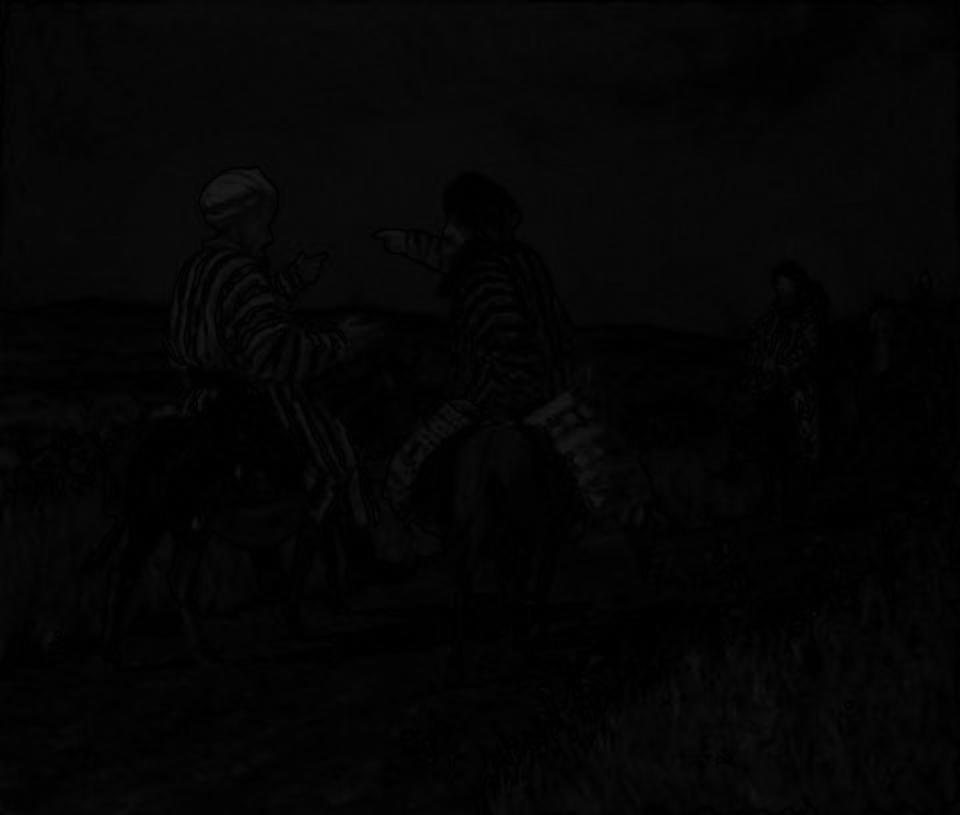

In [64]:
difference = numpy.abs(
    grayscale_naive.astype(numpy.int16) - grayscale_formula.astype(numpy.int16)
).astype(numpy.uint8)
Image.fromarray(difference,  mode="L")

# Большое видео с Фламинго

In [85]:
Video("flamingo.mp4")

In [111]:
def convert_to_grayscale(image):
   return numpy.mean(image, axis=2).astype(numpy.uint8)


def get_grayscale_difference(image1, image2):
    return numpy.abs(
        image1.astype(numpy.int16) - image2.astype(numpy.int16)
    ).astype(numpy.uint8)


video = cv2.VideoCapture("flamingo.mp4")

width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = 30
writer = cv2.VideoWriter(
    "flamingo_difference.mp4",
    cv2.VideoWriter_fourcc(*"mp4v"),
    fps,
    (width, height)
)

try:
    last_grayscale = None
    while True:
        success, frame = video.read()
        if not success:
            break
    
        current_grayscale = convert_to_grayscale(frame)
        if last_grayscale is None:
             difference = numpy.zeros_like(current_grayscale)
        else:
            difference = get_grayscale_difference(current_grayscale, last_grayscale)
        last_grayscale = current_grayscale

        difference_bgr = cv2.cvtColor(difference, cv2.COLOR_GRAY2BGR)
        writer.write(difference_bgr)
        
except Exception as e:
    print(e)
    
finally:
    writer.release()

In [112]:
Video("flamingo_difference.mp4")